# Anopheles stephensi Simulation Results Analysis

This notebook analyses the output of the multi‑agent simulation, focusing on population dynamics, environmental correlations, spatial clustering, and proximity to breeding sites.

## Configuration
Modify the `INPUT_FILE_PATH` variable below to point to your merged snapshot CSV file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy.spatial import cKDTree
import os

# ========== CONFIGURATION ==========
TICKS_PER_DAY = 96
MINUTES_PER_TICK = 15
SIMULATION_START_DATE = datetime(2025, 9, 1)
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# Adjust this path to your actual merged snapshot file
INPUT_FILE_PATH = "results/merged_snapshots_20260414_121407.csv"
OUTPUT_FILE_FOLDER = "output"

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_FILE_FOLDER, exist_ok=True)

# ========== LOAD DATA ==========
df = pd.read_csv(INPUT_FILE_PATH)
mosquito_df = df[df['Layer'] == 'Mosquitoes'].copy()
watertank_df = df[df['Layer'] == 'WaterTanks'].copy()

print(f"Loaded {len(mosquito_df)} mosquito records and {len(watertank_df)} water tank records")
print(f"Time range: ticks {mosquito_df['TickCount'].min()} to {mosquito_df['TickCount'].max()}")

Loaded 1012804 mosquito records and 568748 water tank records
Time range: ticks 100 to 700


## 1. Temporal Trends
Compute daily population counts per life stage and average environmental variables.

In [2]:
# Add day column
mosquito_df['Day'] = mosquito_df['TickCount'] / TICKS_PER_DAY
daily_pop = mosquito_df.groupby('Day').size()
stage_pop = mosquito_df.groupby(['Day', 'Stage']).size().unstack(fill_value=0)

# Average temperature and elevation per day
daily_env = mosquito_df.groupby('Day')[['t2m', 'Elevation']].mean()

print("Daily population (first 5 days):")
print(daily_pop.head())
print("\nDaily stage counts (first 5 days):")
print(stage_pop.head())

Daily population (first 5 days):
Day
1.041667    249307
2.083333    232682
3.125000    199550
4.166667    153373
5.208333    104969
dtype: int64

Daily stage counts (first 5 days):
Stage      ADULT  LARVA   PUPA
Day                           
1.041667  149543  62242  37522
2.083333  139835  57774  35073
3.125000  120267  49025  30258
4.166667   92514  37505  23354
5.208333   63445  25355  16169


## 2. Environmental Correlation (Full Simulation)
Temperature trend across all ticks, using water tank data as a proxy.

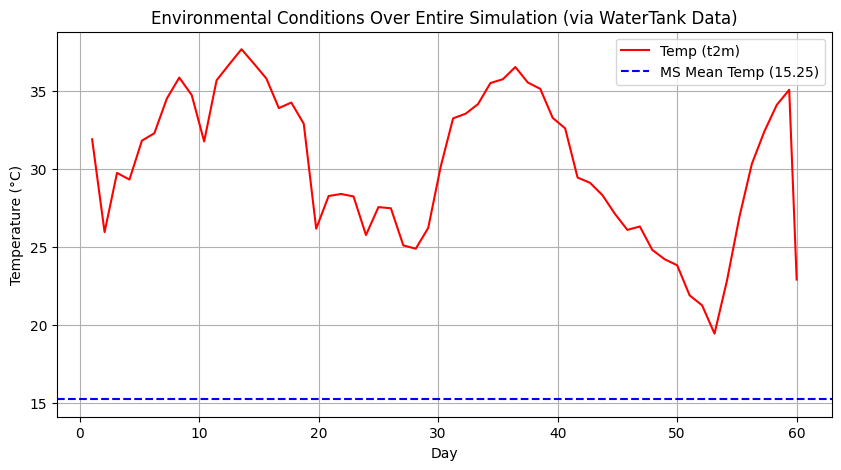

In [3]:
env_trend = watertank_df.groupby('TickCount')[['t2m', 'tp']].mean()

plt.figure(figsize=(10, 5))
plt.plot(env_trend.index / TICKS_PER_DAY, env_trend['t2m'], label='Temp (t2m)', color='red')
plt.axhline(y=15.25, color='blue', linestyle='--', label='MS Mean Temp (15.25)')
plt.title('Environmental Conditions Over Entire Simulation (via WaterTank Data)')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.savefig(f'{OUTPUT_FILE_FOLDER}/env_full_trend.png', dpi=300)
plt.show()

## 3. Spatial Proximity to Breeding Sites
For a subset of ticks (early, mid, late), we compute the average distance of adult mosquitoes to the nearest water tank.

In [4]:
representative_ticks = sorted(mosquito_df['TickCount'].unique())
# Pick 4 snapshots: first, one third, two thirds, last
indices = [0, len(representative_ticks)//3, 2*len(representative_ticks)//3, len(representative_ticks)-1]
target_ticks = [representative_ticks[i] for i in indices]

proximity_results = []

for tick in target_ticks:
    m_subset = mosquito_df[(mosquito_df['TickCount'] == tick) & (mosquito_df['Stage'] == 'ADULT')]
    w_subset = watertank_df[watertank_df['TickCount'] == tick]
    
    if w_subset.empty:
        w_subset = watertank_df[watertank_df['TickCount'] == watertank_df['TickCount'].min()]
        
    if not m_subset.empty and not w_subset.empty:
        tree = cKDTree(w_subset[['X', 'Y']].values)
        distances, _ = tree.query(m_subset[['X', 'Y']].values)
        proximity_results.append({
            'Tick': tick,
            'Day': tick / TICKS_PER_DAY,
            'AvgDist': np.mean(distances),
            'MedianDist': np.median(distances),
            'Count': len(m_subset)
        })

proximity_summary = pd.DataFrame(proximity_results)
proximity_summary

,Tick,Day,AvgDist,MedianDist,Count
0,100,1.041667,0.000421,0.000294,149543
1,300,3.125000,0.000423,0.000294,120267
2,500,5.208333,0.000421,0.000295,63445
3,700,7.291667,0.000425,0.000296,8739


## 4. Visualizations

### 4.1 Population and Stage Dynamics + Temperature Correlation

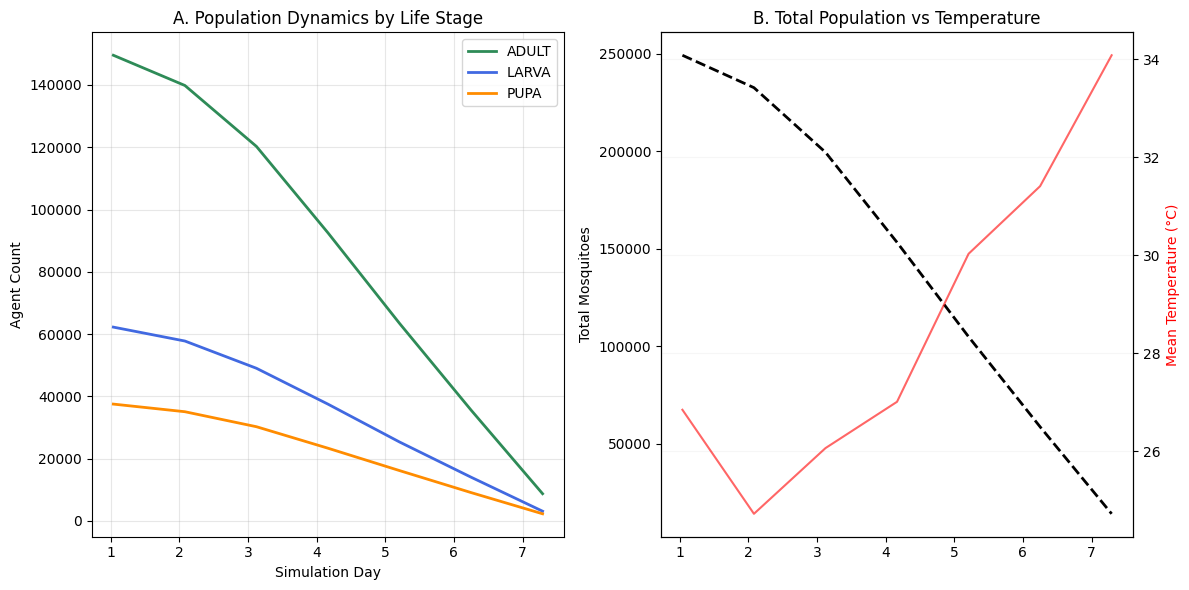

In [5]:
plt.figure(figsize=(12, 6))

# Left: Stage dynamics
plt.subplot(1, 2, 1)
for stage in STAGE_COLORS:
    if stage in stage_pop.columns:
        plt.plot(stage_pop.index, stage_pop[stage], label=stage, color=STAGE_COLORS[stage], linewidth=2)
plt.title('A. Population Dynamics by Life Stage')
plt.xlabel('Simulation Day')
plt.ylabel('Agent Count')
plt.legend()
plt.grid(True, alpha=0.3)

# Right: Total population vs temperature
plt.subplot(1, 2, 2)
ax1 = plt.gca()
ax1.plot(daily_pop.index, daily_pop.values, color='black', label='Total Pop', linewidth=2, linestyle='--')
ax1.set_ylabel('Total Mosquitoes')
ax2 = ax1.twinx()
ax2.plot(daily_env.index, daily_env['t2m'], color='red', label='Temp (°C)', alpha=0.6)
ax2.set_ylabel('Mean Temperature (°C)', color='red')
plt.title('B. Total Population vs Temperature')
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FILE_FOLDER}/dynamics_analysis.png', dpi=300)
plt.show()

### 4.2 Spatial Clustering Heatmaps (Selected Ticks)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, tick in enumerate(target_ticks):
    ax = axes[i]
    m_data = mosquito_df[mosquito_df['TickCount'] == tick]
    w_data = watertank_df[watertank_df['TickCount'] == tick]
    if w_data.empty:
        w_data = watertank_df[watertank_df['TickCount'] == watertank_df['TickCount'].min()]
    
    # Water tank locations (background)
    ax.scatter(w_data['X'], w_data['Y'], s=2, marker='x', color='black', alpha=0.2, linewidths=1.5, label='Water Sources')
    
    # Mosquito density heatmap
    if len(m_data) > 5:
        sns.kdeplot(data=m_data, x='X', y='Y', fill=True, cmap='viridis', alpha=0.6, ax=ax)
    
    # Mosquito scatter by stage
    for stage, color in STAGE_COLORS.items():
        subset = m_data[m_data['Stage'] == stage]
        ax.scatter(subset['X'], subset['Y'], c=color, s=10, alpha=0.7, label=stage if i==0 else "")
    
    day_val = tick / TICKS_PER_DAY
    ax.set_title(f'Day {day_val:.1f} (N={len(m_data)})')
    if i == 0:
        ax.legend(loc='upper right', markerscale=5)

plt.suptitle('Spatio-Temporal Distribution of An. stephensi', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'{OUTPUT_FILE_FOLDER}/spatial_clustering.png', dpi=300)
plt.show()

### 4.3 Proximity to Nearest Water Source Over Time

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(proximity_summary['Day'], proximity_summary['AvgDist'] * 111, marker='o', color='darkred', label='Avg Dist (km)')
plt.title('Mosquito Proximity to Nearest Water Source (Potential Breeding Sites)')
plt.xlabel('Day')
plt.ylabel('Mean Distance (km)')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_FILE_FOLDER}/proximity_trend.png', dpi=300)
plt.show()

## 5. Export Summary Statistics
Save daily dynamics and proximity stats as CSV files for further analysis.

In [ ]:
proximity_summary.to_csv(f'{OUTPUT_FILE_FOLDER}/proximity_stats.csv', index=False)
daily_stats = pd.concat([daily_pop.rename('TotalPop'), stage_pop, daily_env], axis=1)
daily_stats.to_csv(f'{OUTPUT_FILE_FOLDER}/daily_dynamics_stats.csv')

# Print key metrics
peak_pop = daily_stats['TotalPop'].max()
final_pop = daily_stats['TotalPop'].iloc[-1]
avg_temp = daily_stats['t2m'].mean()

print(f"Peak population: {peak_pop}")
print(f"Final population: {final_pop}")
print(f"Average temperature: {avg_temp:.2f}°C")
print(f"\nSummary files saved to '{OUTPUT_FILE_FOLDER}/'")
print(f"  - daily_dynamics_stats.csv")
print(f"  - proximity_stats.csv")
print(f"  - dynamics_analysis.png")
print(f"  - spatial_clustering.png")
print(f"  - proximity_trend.png")
print(f"  - env_full_trend.png")